# Backtest 010 — Linear Regression Prediction Channel: Dip-Reclaim

Single long-only strategy derived from the MQL5 article
[*Linear Regression Prediction Channels*](https://www.mql5.com/en/articles/23130).

A rolling **OLS regression line** is fitted over the last `reg_window` bars of
each symbol's close, with a Student's-t **prediction interval (PI)** scatter
band around it:

`PI = ŷ ± t·s·√(1 + 1/n + (x−x̄)²/Sxx)`

**Trading rules (buy the dip, sell into strength):**

| | Rule |
|--|------|
| **Entry** | close crosses **above the lower PI band** — price reclaims the statistically-cheap zone |
| **Exit**  | close crosses **below the upper PI band** — momentum fades after reaching the rich zone |
| **Stop**  | protective swing-low hard stop (`sl_stop`, capped at `max_sl`) — safety net for dips that keep falling |

Optional gates: a per-bar **slope filter** (`slope_min_pct`) and a per-symbol
**ATR% gate** (both from the `backtest_005` family).

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os, sys, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numba as nb
import vectorbt as vbt
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import talib
ROOT = pathlib.Path('..').resolve()
sys.path.insert(0, str(ROOT))
# Numba disk cache from the FastAPI runtime stores module paths as `app.*`.
sys.path.insert(0, str(ROOT / 'backend'))
import backend.app
import backend.app.services
import backend.app.services.indicators
sys.modules.setdefault('app', backend.app)
sys.modules.setdefault('app.services', backend.app.services)
sys.modules.setdefault('app.services.indicators', backend.app.services.indicators)
from backend.app.services.indicators.common import shift_2d
from backend.app.services.indicators.linreg_channel import (
    linreg_prediction_channels, linreg_channel_2d, student_t_crit,
)

plt.style.use('dark_background')
print('imports ok')

{'v1': {'bb_window': 23, 'bb_multiplier': 1.5, 'bb_matype': 2, 'kc_window': 21, 'kc_multiplier': 0.9, 'kc_atr_period': 5, 'donichan_window': 11, 'osc_smoothing_period': 9, 'low_stop_lookback': 5, 'atr_period': 10, 'atr_multiplier': 1.9, 'max_sl': 0.06}, 'v2': {'bb_window': 22, 'bb_multiplier': 2.0, 'bb_matype': 0, 'kc_window': 16, 'kc_multiplier': 0.8, 'kc_atr_period': 13, 'donichan_window': 11, 'osc_smoothing_period': 8, 'low_stop_lookback': 5, 'atr_period': 10, 'atr_multiplier': 2.2, 'max_sl': 0.07}, 'v3': {'bb_window': 11, 'bb_multiplier': 0.9, 'bb_matype': 0, 'kc_window': 20, 'kc_multiplier': 1.9000000000000001, 'kc_atr_period': 19, 'donichan_window': 11, 'osc_smoothing_period': 9, 'low_stop_lookback': 3, 'atr_period': 5, 'atr_multiplier': 3.5, 'max_sl': 0.14, 'william_vix_period': 18, 'consecutive_neg_threshold': 4}}
imports ok


## 1. Load Data

In [ ]:
from backend.app.services.data_loader import load_stocks

BENCHMARK = 'VNINDEX'
DATA_START = '2019-01-01'

df_raw = load_stocks(exclude=[], refresh=False)
df_raw = df_raw.loc[DATA_START:]

open_  = df_raw['open']
high   = df_raw['high']
low    = df_raw['low']
close  = df_raw['close']
volume = df_raw['volume']

valid_syms = close.columns[close.isna().mean() < 0.2]
close  = close[valid_syms].ffill()
high   = high[valid_syms].ffill()
low    = low[valid_syms].ffill()
open_  = open_[valid_syms].ffill()
volume = volume[valid_syms].ffill().fillna(0)

if BENCHMARK in close.columns:
    bm_close  = close[BENCHMARK]
    bm_volume = volume[BENCHMARK]
else:
    bm_close  = close.mean(axis=1)
    bm_volume = volume.mean(axis=1)
    print(f'BENCHMARK {BENCHMARK!r} not found — using equal-weight index')

print(f'Shape : {close.shape}  |  {close.index[0].date()} -> {close.index[-1].date()}')
print(f'Symbols: {len(valid_syms)}  |  Benchmark: {BENCHMARK}')
close.tail(3)

HDF5 not found — fetching from DeltaLake …
Loaded 985 symbols × 2499 bars from DeltaLake
Saved to stocks_data_latest.h5
Shape: (2499, 985)  |  2016-07-15 → 2026-07-14
Shape : (1879, 197)  |  2019-01-02 -> 2026-07-14
Symbols: 197  |  Benchmark: VNINDEX


symbol,AAA,ABB,ACB,ACV,ADS,AGG,AGR,ANV,APH,ASM,...,VNINDEX,VNM,VOS,VPB,VPG,VPI,VRE,VSC,VTP,YEG
date,,,,,,,,,,,,,,,,,,,,,
2026-07-10,7.25,17.6,22.55,42.5,7.89,11.50,15.35,19.60,5.49,6.17,...,1828.34,56.6,11.90,26.7,2.00,62.4,26.35,16.30,53.85,8.72
2026-07-13,7.23,17.0,22.45,42.9,7.70,11.50,14.50,18.85,5.56,6.14,...,1800.54,55.4,11.85,26.4,2.02,61.1,25.90,15.55,52.32,8.27
2026-07-14,7.25,17.0,22.85,42.8,7.60,11.45,14.65,18.80,5.58,6.19,...,1806.63,56.0,11.85,26.5,1.96,61.8,25.60,15.90,52.50,8.32


In [3]:
IS_FRAC   = 0.6
split_idx = int(len(close) * IS_FRAC)
oos_start = close.index[split_idx]

close_is   = close.iloc[:split_idx];  close_oos  = close.iloc[split_idx:]
high_is    = high.iloc[:split_idx];   high_oos   = high.iloc[split_idx:]
low_is     = low.iloc[:split_idx];    low_oos    = low.iloc[split_idx:]
open_is    = open_.iloc[:split_idx];  open_oos   = open_.iloc[split_idx:]
volume_is  = volume.iloc[:split_idx]; volume_oos = volume.iloc[split_idx:]

print(f'IS  {close_is.index[0].date()} -> {close_is.index[-1].date()}  ({len(close_is)} bars)')
print(f'OOS {close_oos.index[0].date()} -> {close_oos.index[-1].date()}  ({len(close_oos)} bars)')

IS  2019-01-02 -> 2023-07-07  (1127 bars)
OOS 2023-07-10 -> 2026-07-14  (752 bars)


## 2. Signal Helpers — Dip-Reclaim on the PI Channel

`compute_signals` fits the regression channel and fires an **entry** when close
crosses **above the lower PI band**. `compute_exits` fires an **exit** when
close crosses **below the upper PI band**, and supplies a swing-low hard stop.
Both recompute the channel from the same `reg_window` / `confidence` so the
entry and exit bands are consistent.

In [4]:
def _crossed_above(series_np, band_np):
    """True on the bar where series crosses from <=band to >band."""
    prev_s = shift_2d(series_np, 1)
    prev_b = shift_2d(band_np,   1)
    return (prev_s <= prev_b) & (series_np > band_np) & ~np.isnan(prev_b)


def _crossed_below(series_np, band_np):
    """True on the bar where series crosses from >=band to <band."""
    prev_s = shift_2d(series_np, 1)
    prev_b = shift_2d(band_np,   1)
    return (prev_s >= prev_b) & (series_np < band_np) & ~np.isnan(prev_b)


def _pi_bands(close, reg_window, confidence):
    """Return (reg, slope, pi_lower, pi_upper) numpy arrays for the close panel."""
    t_crit = student_t_crit(reg_window, confidence)
    arr = close.to_numpy(dtype=np.float64)
    reg, slope, _ci_u, _ci_l, pi_u, pi_l = linreg_channel_2d(arr, reg_window, float(t_crit))
    return arr, reg, slope, pi_l, pi_u


def compute_signals(
    close, high, low,
    open_=None, volume=None,
    reg_window:       int   = 50,    # OLS lookback (article default 50, >=5)
    confidence:       float = 0.95,  # Student's-t central mass (0.50-0.99)
    slope_min_pct:    float = -1.0,  # require per-bar slope/price*100 > this (set very low to disable)
    use_atr_pct_gate: bool  = True,
    atr_pct_period:   int   = 14,
    atr_pct_max:      float = 5.0,   # block entries when ATR%/close*100 >= threshold
):
    """ENTRY: close crosses above the lower prediction-interval band (buy the dip).

    Returns a (bars x symbols) bool DataFrame of entry signals.
    """
    close_np, reg, slope, pi_lower, _pi_upper = _pi_bands(close, reg_window, confidence)

    with np.errstate(divide='ignore', invalid='ignore'):
        slope_pct_np = np.where(reg != 0, slope / reg * 100.0, np.nan)
    slope_gate = slope_pct_np > slope_min_pct

    if use_atr_pct_gate:
        ATR = vbt.IndicatorFactory.from_talib('ATR')
        atr_pct_np = (
            ATR.run(high, low, close, timeperiod=atr_pct_period).real.to_numpy()
            / np.where(close_np == 0, np.nan, close_np) * 100
        )
        atr_gate = np.where(np.isnan(atr_pct_np), True, atr_pct_np < atr_pct_max)
    else:
        atr_gate = np.ones_like(close_np, dtype=np.bool_)

    entries_np = _crossed_above(close_np, pi_lower) # & slope_gate & atr_gate
    entries_np = np.where(np.isnan(entries_np), False, entries_np).astype(bool)
    return pd.DataFrame(entries_np, index=close.index, columns=close.columns)


def compute_exits(close, high, low,
                  reg_window: int = 50, confidence: float = 0.95,
                  low_stop_lookback: int = 5, max_sl: float = 0.1):
    """EXIT: close crosses below the upper prediction-interval band.

    Returns (exits_df, sl_stop_df). ``sl_stop_df`` is a per-bar swing-low hard
    stop (relative distance, capped at ``max_sl``) passed as ``sl_stop=`` to
    vbt — a safety net for dip buys that keep falling instead of reverting.
    """
    close_np, _reg, _slope, _pi_lower, pi_upper = _pi_bands(close, reg_window, confidence)

    exits_np = _crossed_below(close_np, pi_upper)
    exits_np = np.where(np.isnan(exits_np), False, exits_np).astype(bool)
    exits_df = pd.DataFrame(exits_np, index=close.index, columns=close.columns)

    MIN        = vbt.IndicatorFactory.from_talib('MIN')
    lowest_low = MIN.run(low, timeperiod=low_stop_lookback).real
    sl_stop_df = ((close - lowest_low) / close).clip(lower=0, upper=max_sl)
    return exits_df, sl_stop_df


print('Signal functions defined')

Signal functions defined


## 3. Baseline Run (default params)

In [5]:
# VNINDEX Buy & Hold — full-sample reference
bh_entries = pd.DataFrame(False, index=close.index, columns=[BENCHMARK])
bh_entries.iloc[0, 0] = True
bh_exits = pd.DataFrame(False, index=close.index, columns=[BENCHMARK])
pf_bh = vbt.Portfolio.from_signals(
    close=close[[BENCHMARK]], entries=bh_entries, exits=bh_exits,
    freq='1d', group_by=['symbol'], cash_sharing=False, init_cash=100,
)
print(f'VNINDEX Buy&Hold (full)  Total Ret={float(np.atleast_1d(pf_bh.total_return())[0]):.1%}  '
      f'Sharpe={float(np.atleast_1d(pf_bh.sharpe_ratio())[0]):.3f}')

e = compute_signals(close_is, high_is, low_is, open_is, volume_is)
x, sl = compute_exits(close_is, high_is, low_is)
pf = vbt.Portfolio.from_signals(close=close_is, entries=e, exits=x, freq='1d',
                                group_by=['symbol'], cash_sharing=False, sl_stop=sl)
print(f'  dip-reclaim  entries={int(e.values.sum())}  exits={int(x.values.sum())}  '
      f'mean Sharpe={pf.sharpe_ratio().mean():.3f}  mean Ret={pf.total_return().mean():.1%}  '
      f'trades={int(pf.trades.count().sum())}')

VNINDEX Buy&Hold (full)  Total Ret=102.6%  Sharpe=0.704
  dip-reclaim  entries=4613  exits=4777  mean Sharpe=0.280  mean Ret=33.4%  trades=3757


## 4. Optuna Multi-Objective Optimisation

Search maximising **(mean total return %, mean Sortino)** on the in-sample
slice. Channel params (`reg_window`, `confidence`, `slope_min_pct`), the ATR%
gate, and the swing-low stop are tuned jointly. Entry/exit bands share the same
channel parameters.

In [6]:
def objective(trial):
    reg_window    = trial.suggest_int  ('reg_window',    20, 100, step=5)
    confidence    = trial.suggest_float('confidence',    0.80, 0.99, step=0.01)
    slope_min_pct = trial.suggest_float('slope_min_pct', -0.30, 0.30, step=0.02)

    use_atr_pct_gate = trial.suggest_categorical('use_atr_pct_gate', [True, False])
    atr_pct_period   = trial.suggest_int('atr_pct_period', 5, 21)
    atr_pct_max      = trial.suggest_int('atr_pct_max',    3, 10)

    low_stop_lookback = trial.suggest_int  ('low_stop_lookback', 2, 5)
    max_sl            = trial.suggest_float('max_sl',            0.04, 0.15, step=0.01)

    try:
        entries = compute_signals(
            close_is, high_is, low_is, open_is, volume_is,
            reg_window=reg_window, confidence=confidence, slope_min_pct=slope_min_pct,
            use_atr_pct_gate=use_atr_pct_gate,
            atr_pct_period=atr_pct_period, atr_pct_max=atr_pct_max,
        )
        exits, sl_stop_df = compute_exits(
            close_is, high_is, low_is,
            reg_window=reg_window, confidence=confidence,
            low_stop_lookback=low_stop_lookback, max_sl=max_sl,
        )
        pf = vbt.Portfolio.from_signals(
            close=close_is, entries=entries, exits=exits,
            freq='1d', group_by=['symbol'], cash_sharing=False, sl_stop=sl_stop_df,
        )
        total_ret = pf.total_return().replace([np.inf, -np.inf], np.nan).dropna()
        sharpe    = pf.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()
        sortino   = pf.sortino_ratio().replace([np.inf, -np.inf], np.nan).dropna()

        if len(total_ret) == 0:
            return -999.0, -999.0

        mean_ret     = float(total_ret.mean() * 100)
        mean_sortino = float(sortino.mean()) if len(sortino) > 0 else -999.0

        # penalise if <30% of symbols profitable
        if len(sharpe) > 0 and (sharpe > 0).mean() < 0.3:
            mean_ret     *= 0.5
            mean_sortino *= 0.5
        return mean_ret, mean_sortino
    except Exception:
        return -999.0, -999.0


N_TRIALS = 800   # raise for better coverage

study = optuna.create_study(
    directions=['maximize', 'maximize'],
    study_name='lrchan_dip_reclaim',
    sampler=optuna.samplers.NSGAIISampler(seed=42),
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
print(f'Done. Pareto front: {len(study.best_trials)} trials')

  0%|          | 0/800 [00:00<?, ?it/s]

Done. Pareto front: 302 trials


## 5. Select Best Params

In [7]:
SELECTION = 'balanced'   # 'best_return' | 'best_sortino' | 'balanced'

def pick_best(study, selection=SELECTION):
    if selection == 'best_return':
        return max(study.best_trials, key=lambda t: t.values[0])
    if selection == 'best_sortino':
        return max(study.best_trials, key=lambda t: t.values[1])
    def score(t):
        return 0.4 * (t.values[0] + 100) / 200 + 0.6 * (t.values[1] + 10) / 20
    return max(study.best_trials, key=score)

best_trial  = pick_best(study)
best_params = best_trial.params

print(f'Selection strategy: {SELECTION}')
print(f'Trial #{best_trial.number}  Total Return={best_trial.values[0]:.2f}%  Sortino={best_trial.values[1]:.3f}')
pd.Series(best_params, name='value').to_frame()

Selection strategy: balanced
Trial #279  Total Return=75.14%  Sortino=0.939


,value
reg_window,100
confidence,0.81
slope_min_pct,-0.14
use_atr_pct_gate,False
atr_pct_period,14
atr_pct_max,5
low_stop_lookback,2
max_sl,0.05


## 6. Out-of-Sample Evaluation — IS params on held-out OOS slice

In [8]:
bm_entries_oos = pd.DataFrame(False, index=close_oos.index, columns=[BENCHMARK])
bm_entries_oos.iloc[0, 0] = True
bm_exits_oos = pd.DataFrame(False, index=close_oos.index, columns=[BENCHMARK])
pf_base = vbt.Portfolio.from_signals(
    close=close_oos[[BENCHMARK]], entries=bm_entries_oos, exits=bm_exits_oos,
    freq='1d', group_by=['symbol'], cash_sharing=False, init_cash=100,
)
bh_sharpe_oos = float(np.atleast_1d(pf_base.sharpe_ratio())[0])
bh_ret_oos    = float(np.atleast_1d(pf_base.total_return())[0])
print(f'VNINDEX Buy & Hold (OOS)  Total Return={bh_ret_oos:.1%}  Sharpe={bh_sharpe_oos:.3f}')

p = best_params
entries_oos = compute_signals(
    close_oos, high_oos, low_oos, open_oos, volume_oos,
    reg_window=p['reg_window'], confidence=p['confidence'], slope_min_pct=p['slope_min_pct'],
    use_atr_pct_gate=p['use_atr_pct_gate'],
    atr_pct_period=p['atr_pct_period'], atr_pct_max=p['atr_pct_max'],
)
exits_oos, sl_stop_oos = compute_exits(
    close_oos, high_oos, low_oos,
    reg_window=p['reg_window'], confidence=p['confidence'],
    low_stop_lookback=p['low_stop_lookback'], max_sl=p['max_sl'],
)
pf_oos = vbt.Portfolio.from_signals(
    close=close_oos, entries=entries_oos, exits=exits_oos,
    freq='1d', group_by=['symbol'], cash_sharing=False, sl_stop=sl_stop_oos,
)
print(f'  dip-reclaim  Sharpe={pf_oos.sharpe_ratio().mean():.3f}  '
      f'vs VNINDEX {bh_sharpe_oos:.3f}  (d{pf_oos.sharpe_ratio().mean()-bh_sharpe_oos:+.3f})')
print('OOS portfolio built.')

VNINDEX Buy & Hold (OOS)  Total Return=57.2%  Sharpe=1.101
  dip-reclaim  Sharpe=0.170  vs VNINDEX 1.101  (d-0.931)
OOS portfolio built.


## 7. Stats Table

In [9]:
def strat_stats(name, pf):
    def _s(x):
        return pd.Series(np.atleast_1d(x), dtype=float)
    s  = _s(pf.sharpe_ratio()).replace([np.inf, -np.inf], np.nan).dropna()
    tr = _s(pf.total_return())
    dd = _s(pf.max_drawdown())
    try:
        n_trades  = int(pf.trades.count().sum())
        avg_ret   = f'{_s(pf.trades.returns.mean()).mean():.2%}'
        win_rate  = f'{_s(pf.trades.win_rate()).mean():.1%}'
        pf_factor = round(_s(pf.trades.profit_factor()).mean(), 3)
    except Exception:
        n_trades, avg_ret, win_rate, pf_factor = 0, 'N/A', 'N/A', float('nan')
    return {
        'Strategy': name,
        'Sharpe mean': round(s.mean(), 3),
        'Sharpe median': round(s.median(), 3),
        'Sharpe > 0': f'{(s > 0).sum()}/{len(s)}',
        'Sortino mean': round(_s(pf.sortino_ratio()).replace([np.inf,-np.inf],np.nan).dropna().mean(), 3),
        'Calmar mean': round(_s(pf.calmar_ratio()).replace([np.inf,-np.inf],np.nan).dropna().mean(), 3),
        'Total Ret mean': f'{tr.mean():.1%}',
        'Total Ret median': f'{tr.median():.1%}',
        'Max DD mean': f'{dd.mean():.1%}',
        'Max DD worst': f'{dd.min():.1%}',
        'N Trades': n_trades,
        'Avg Trade Ret': avg_ret,
        'Win Rate': win_rate,
        'Profit Factor': pf_factor,
    }

rows = [strat_stats('VNINDEX Buy & Hold', pf_base),
        strat_stats('LR-Channel Dip-Reclaim (OOS)', pf_oos)]
comp_df = pd.DataFrame(rows).set_index('Strategy')
print('=== COMPARISON (OOS) ===')
comp_df.T

=== COMPARISON (OOS) ===


Strategy,VNINDEX Buy & Hold,LR-Channel Dip-Reclaim (OOS)
Sharpe mean,1.101,0.17
Sharpe median,1.101,0.115
Sharpe > 0,1/1,112/197
Sortino mean,1.49,0.325
Calmar mean,1.357,0.249
Total Ret mean,57.2%,11.7%
Total Ret median,57.2%,0.7%
Max DD mean,-18.1%,-25.3%
Max DD worst,-18.1%,-54.2%
N Trades,1,2369


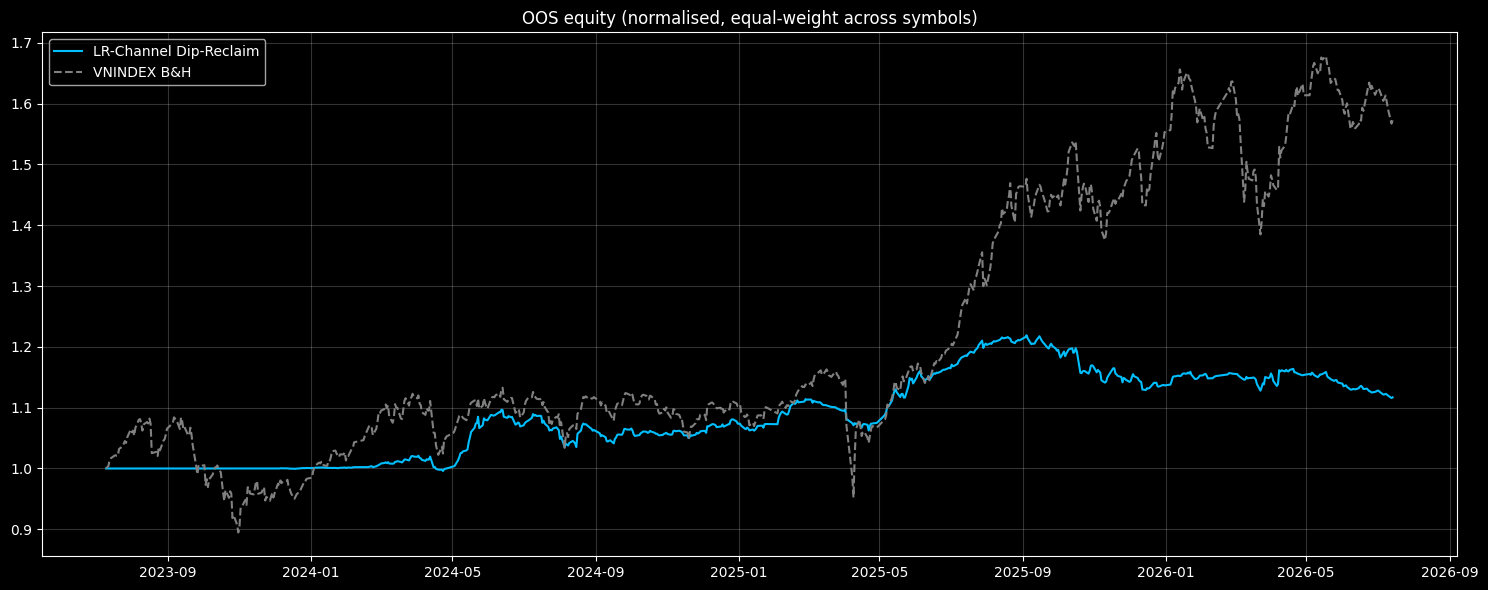

In [10]:
fig, ax = plt.subplots(figsize=(15, 6))
eq = pf_oos.value().mean(axis=1)
ax.plot(eq.index, eq / eq.iloc[0], color='deepskyblue', label='LR-Channel Dip-Reclaim')
bh = pf_base.value()
bh = bh.iloc[:, 0] if isinstance(bh, pd.DataFrame) else bh
ax.plot(bh.index, bh / bh.iloc[0], '--', color='grey', label='VNINDEX B&H')
ax.set_title('OOS equity (normalised, equal-weight across symbols)')
ax.legend(); ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()

### Distribution — per-symbol Total Return & Sharpe (OOS)

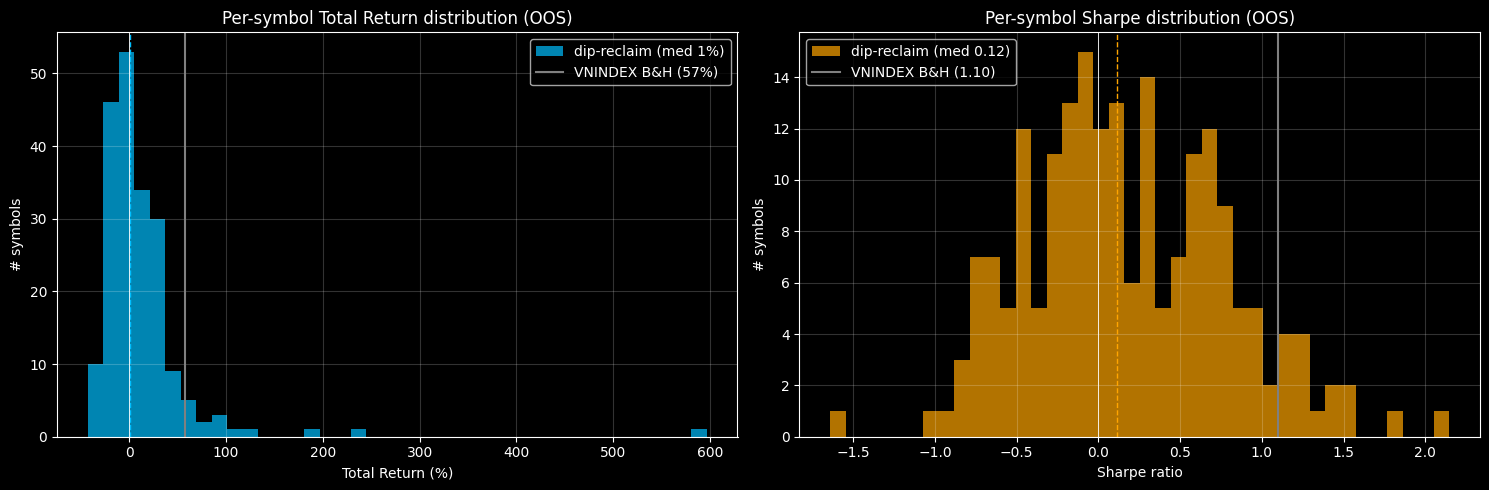

In [11]:
def _clean(x):
    return pd.Series(np.atleast_1d(x), dtype=float).replace([np.inf, -np.inf], np.nan).dropna()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

tr = _clean(pf_oos.total_return()) * 100
axes[0].hist(tr, bins=40, alpha=0.7, color='deepskyblue', label=f'dip-reclaim (med {tr.median():.0f}%)')
axes[0].axvline(tr.median(), color='deepskyblue', ls='--', lw=1)
axes[0].axvline(bh_ret_oos * 100, color='grey', ls='-', lw=1.5, label=f'VNINDEX B&H ({bh_ret_oos:.0%})')
axes[0].axvline(0, color='white', lw=0.6)
axes[0].set_title('Per-symbol Total Return distribution (OOS)')
axes[0].set_xlabel('Total Return (%)'); axes[0].set_ylabel('# symbols')
axes[0].legend(); axes[0].grid(alpha=0.2)

sh = _clean(pf_oos.sharpe_ratio())
axes[1].hist(sh, bins=40, alpha=0.7, color='orange', label=f'dip-reclaim (med {sh.median():.2f})')
axes[1].axvline(sh.median(), color='orange', ls='--', lw=1)
axes[1].axvline(bh_sharpe_oos, color='grey', ls='-', lw=1.5, label=f'VNINDEX B&H ({bh_sharpe_oos:.2f})')
axes[1].axvline(0, color='white', lw=0.6)
axes[1].set_title('Per-symbol Sharpe distribution (OOS)')
axes[1].set_xlabel('Sharpe ratio'); axes[1].set_ylabel('# symbols')
axes[1].legend(); axes[1].grid(alpha=0.2)

plt.tight_layout(); plt.show()

### Channel Visual — entries (lower-PI reclaim) & exits (upper-PI break)

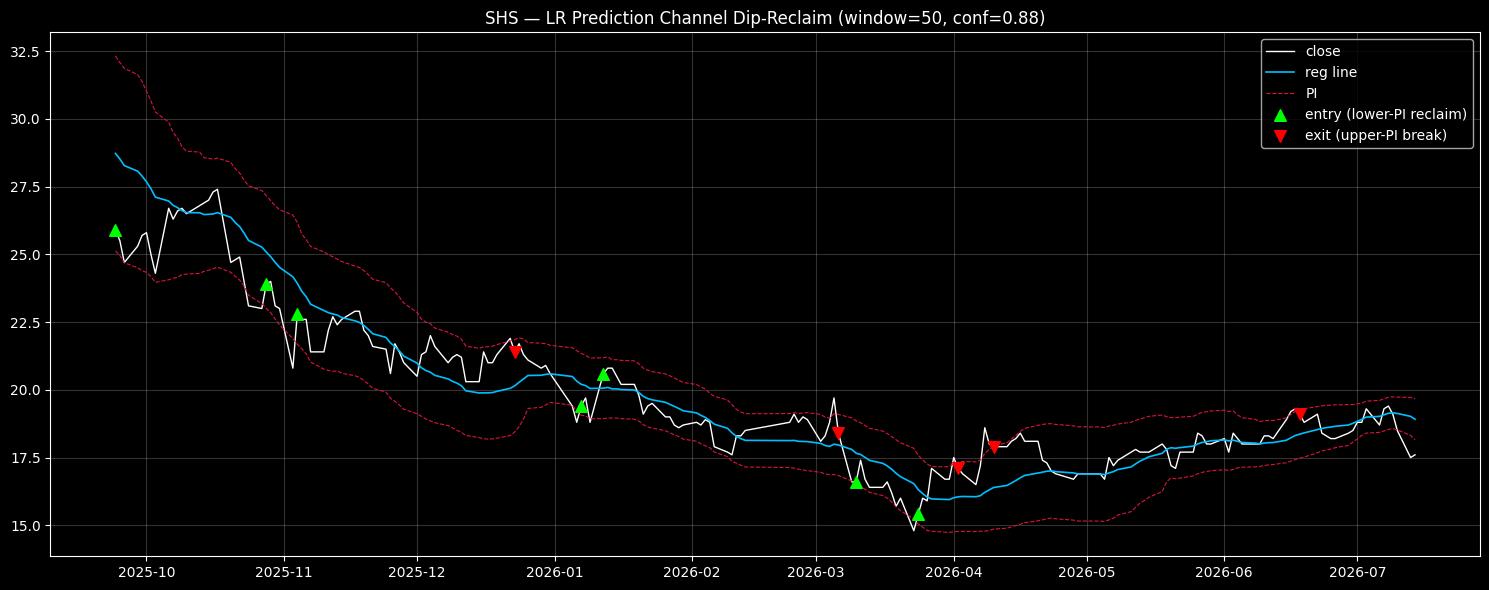

In [23]:
p = best_params
reg_window = 50 # p.get('reg_window', 50)
confidence = 0.88 #p.get('confidence', 0.95)
slope_min_pct = p.get('slope_min_pct', -0.30)
use_atr_pct_gate = p.get('use_atr_pct_gate', True)
atr_pct_period = p.get('atr_pct_period', 14)
atr_pct_max = p.get('atr_pct_max', 5.0)
def plot_channel(SYM):
    ch = linreg_prediction_channels(close[[SYM]], window=reg_window, confidence=confidence)

    e_sym = compute_signals(close[[SYM]], high[[SYM]], low[[SYM]],
                            reg_window=reg_window, confidence=confidence,
                            slope_min_pct=slope_min_pct, use_atr_pct_gate=use_atr_pct_gate,
                            atr_pct_period=atr_pct_period, atr_pct_max=atr_pct_max)[SYM]
    x_sym, _ = compute_exits(close[[SYM]], high[[SYM]], low[[SYM]],
                            reg_window=reg_window, confidence=confidence,
                            low_stop_lookback=p.get('low_stop_lookback', 5), max_sl=p.get('max_sl', 0.1))
    x_sym = x_sym[SYM]

    sl = slice(-200, None)
    idx = close[SYM].iloc[sl].index
    fig, ax = plt.subplots(figsize=(15, 6))
    ax.plot(close[SYM].iloc[sl], color='white', lw=1.0, label='close')
    ax.plot(ch['reg'][SYM].iloc[sl], color='deepskyblue', lw=1.2, label='reg line')
    ax.plot(ch['pi_upper'][SYM].iloc[sl], color='crimson', lw=0.8, ls='--', label='PI')
    ax.plot(ch['pi_lower'][SYM].iloc[sl], color='crimson', lw=0.8, ls='--')
    ent = e_sym.iloc[sl]; ext = x_sym.iloc[sl]
    ax.scatter(idx[ent.values], close[SYM].iloc[sl][ent.values], marker='^', s=70,
            color='lime', zorder=5, label='entry (lower-PI reclaim)')
    ax.scatter(idx[ext.values], close[SYM].iloc[sl][ext.values], marker='v', s=70,
            color='red', zorder=5, label='exit (upper-PI break)')
    ax.set_title(f'{SYM} — LR Prediction Channel Dip-Reclaim (window={reg_window}, conf={confidence})')
    ax.legend(); ax.grid(alpha=0.2)
    plt.tight_layout(); plt.show()

plot_channel('SHS')

## 9. Live Scan — PI-channel position & entry triggers (latest bar)

Scan the whole universe at the **most recent bar**:

- **Below lower PI** — statistically cheap *watch* list (not yet an entry).
- **Above upper PI** — statistically rich / extended (exit-watch for open longs).
- **Reclaim entry** — close *just crossed back above* the lower PI within the
  last `LOOKBACK` bar(s) — the strategy's actual dip-buy trigger.

`dist_%` = distance from close to the relevant band as a % of price.
`slope_%` = per-bar regression slope as a % of price (channel direction).

In [13]:
# ── Live scan: PI-channel position + dip-reclaim / upper-PI breakout triggers ─
SCAN_REG_WINDOW = 50 # best_params.get('reg_window', 50) # best params = 95, 0.88
SCAN_CONFIDENCE = 0.88 #best_params.get('confidence', 0.95)
TOP_N           = 30   # rows to show per watch-list
LOOKBACK        = 7    # reclaim window: 1 = latest bar only; >1 = within last N bars

def scan_pi_channel(close_panel, reg_window=SCAN_REG_WINDOW, confidence=SCAN_CONFIDENCE,
                    exclude=(BENCHMARK,)):
    """At the last bar, return (date, below_df, above_df) for symbols whose close
    sits outside the prediction-interval channel."""
    ch = linreg_prediction_channels(close_panel, window=reg_window, confidence=confidence)
    last = close_panel.index[-1]
    df = pd.DataFrame({
        'close':    close_panel.iloc[-1],
        'reg':      ch['reg'].iloc[-1],
        'pi_lower': ch['pi_lower'].iloc[-1],
        'pi_upper': ch['pi_upper'].iloc[-1],
        'slope_%':  ch['slope_pct'].iloc[-1],
    }).dropna()
    df = df.drop(index=[s for s in exclude if s in df.index], errors='ignore')

    below = df[df['close'] < df['pi_lower']].copy()
    below['dist_%'] = (df['pi_lower'] - df['close']) / df['close'] * 100   # how far below
    below = below.sort_values('dist_%', ascending=False)

    above = df[df['close'] > df['pi_upper']].copy()
    above['dist_%'] = (df['close'] - df['pi_upper']) / df['close'] * 100   # how far above
    above = above.sort_values('dist_%', ascending=False)

    cols = ['close', 'pi_lower', 'pi_upper', 'reg', 'dist_%', 'slope_%']
    return last, below[cols], above[cols]


def scan_reclaim(close_panel, reg_window=SCAN_REG_WINDOW, confidence=SCAN_CONFIDENCE,
                 lookback=LOOKBACK, exclude=(BENCHMARK,)):
    """Symbols whose close crossed ABOVE the lower PI within the last `lookback`
    bars — the strategy's dip-reclaim entry trigger."""
    entries = compute_signals(close_panel, close_panel, close_panel,   # high/low unused (gates off)
                              reg_window=reg_window, confidence=confidence,
                              use_atr_pct_gate=False)
    ch = linreg_prediction_channels(close_panel, window=reg_window, confidence=confidence)

    recent = entries.iloc[-lookback:]
    fired  = recent.any(axis=0)
    syms   = [s for s in fired.index[fired.values] if s not in exclude]
    trig_date = {s: recent.index[np.where(recent[s].values)[0][-1]] for s in syms}

    out = pd.DataFrame({
        'trigger_date': {s: trig_date[s].date() for s in syms},
        'close':        close_panel[syms].iloc[-1],
        'pi_lower':     ch['pi_lower'][syms].iloc[-1],
        'pi_upper':     ch['pi_upper'][syms].iloc[-1],
        'reg':          ch['reg'][syms].iloc[-1],
        'slope_%':      ch['slope_pct'][syms].iloc[-1],
    })
    out['above_pi_lower_%'] = (out['close'] - out['pi_lower']) / out['close'] * 100
    out['upside_to_reg_%']  = (out['reg']   - out['close'])    / out['close'] * 100
    return out.sort_values('trigger_date', ascending=False)


def scan_breakout(close_panel, reg_window=SCAN_REG_WINDOW, confidence=SCAN_CONFIDENCE,
                  lookback=LOOKBACK, exclude=(BENCHMARK,)):
    """Symbols whose close crossed BELOW the upper PI within the last `lookback`
    bars — the strategy's upper-band rejection / exit trigger."""
    exits, _ = compute_exits(close_panel, close_panel, close_panel,
                             reg_window=reg_window, confidence=confidence)
    ch = linreg_prediction_channels(close_panel, window=reg_window, confidence=confidence)

    recent = exits.iloc[-lookback:]
    fired  = recent.any(axis=0)
    syms   = [s for s in fired.index[fired.values] if s not in exclude]
    trig_date = {s: recent.index[np.where(recent[s].values)[0][-1]] for s in syms}

    out = pd.DataFrame({
        'trigger_date': {s: trig_date[s].date() for s in syms},
        'close':        close_panel[syms].iloc[-1],
        'pi_lower':     ch['pi_lower'][syms].iloc[-1],
        'pi_upper':     ch['pi_upper'][syms].iloc[-1],
        'reg':          ch['reg'][syms].iloc[-1],
        'slope_%':      ch['slope_pct'][syms].iloc[-1],
    })
    out['below_pi_upper_%'] = (out['pi_upper'] - out['close']) / out['close'] * 100
    out['above_reg_%']      = (out['close']   - out['reg'])    / out['close'] * 100
    return out.sort_values('trigger_date', ascending=False)


# ── (A) symbols sitting outside the channel ──────────────────────────────────
scan_date, below_pi, above_pi = scan_pi_channel(close)
print(f'Scan @ {scan_date.date()}   reg_window={SCAN_REG_WINDOW}  confidence={SCAN_CONFIDENCE}')
print(f'  BELOW lower PI (dip-watch): {len(below_pi)}   |   ABOVE upper PI (extended): {len(above_pi)}')

print(f'\n── BELOW lower PI — top {TOP_N} cheapest (largest dist below band) ──')
display(below_pi.head(TOP_N).round(2))
print(f'\n── ABOVE upper PI — top {TOP_N} most extended ──')
display(above_pi.head(TOP_N).round(2))

# ── (B) entry trigger: close just crossed above the lower PI ─────────────────
reclaim = scan_reclaim(close, lookback=7)
print(f'\n── RECLAIM ENTRY — crossed above lower PI within last {LOOKBACK} bar(s): '
      f'{len(reclaim)} symbol(s) ──')
display(reclaim.round(2).sort_values('slope_%', ascending=True))

# ── (C) exit trigger: close crossed below the upper PI ─────────────────────
breakout = scan_breakout(close, lookback=7)
print(f'\n── BREAKOUT EXIT — crossed below upper PI within last {LOOKBACK} bar(s): '
      f'{len(breakout)} symbol(s) ──')
display(breakout.round(2).sort_values('slope_%', ascending=False))

Scan @ 2026-07-14   reg_window=50  confidence=0.88
  BELOW lower PI (dip-watch): 24   |   ABOVE upper PI (extended): 12

── BELOW lower PI — top 30 cheapest (largest dist below band) ──


,close,pi_lower,pi_upper,reg,dist_%,slope_%
symbol,,,,,,
GIL,9.22,10.23,11.39,10.81,10.95,-0.44
PNJ,46.90,48.51,62.51,55.51,3.44,-0.57
SHS,17.60,18.16,19.67,18.91,3.17,0.15
BCM,47.05,48.33,53.16,50.74,2.72,-0.17
VIX,14.70,15.05,16.90,15.98,2.38,-0.40
TPB,15.50,15.78,16.77,16.28,1.83,0.07
VPG,1.96,1.99,2.42,2.21,1.77,-1.42
SHB,12.80,13.00,13.71,13.35,1.53,-0.11
IJC,8.15,8.23,8.78,8.50,1.02,-0.40



── ABOVE upper PI — top 30 most extended ──


,close,pi_lower,pi_upper,reg,dist_%,slope_%
symbol,,,,,,
OIL,14.80,12.16,14.27,13.22,3.57,-0.34
DPM,24.40,21.23,23.59,22.41,3.31,-0.42
SJS,48.50,43.57,47.80,45.69,1.44,-0.47
SCR,5.19,4.71,5.12,4.91,1.35,-0.31
PVC,13.50,11.73,13.36,12.54,1.04,-0.53
ASM,6.19,5.73,6.14,5.93,0.87,-0.01
DIG,12.60,11.24,12.51,11.87,0.73,-0.45
TCH,14.30,13.09,14.22,13.66,0.53,-0.46
PVS,38.80,35.61,38.67,37.14,0.33,-0.17



── RECLAIM ENTRY — crossed above lower PI within last 7 bar(s): 25 symbol(s) ──


,trigger_date,close,pi_lower,pi_upper,reg,slope_%,above_pi_lower_%,upside_to_reg_%
VSC,2026-07-14,15.90,15.85,17.99,16.92,-0.62,0.30,6.42
DPG,2026-07-14,33.65,33.07,37.32,35.19,-0.44,1.74,4.59
HDG,2026-07-08,19.15,18.48,20.27,19.37,-0.36,3.50,1.17
GVR,2026-07-14,30.50,29.72,33.35,31.53,-0.36,2.55,3.39
BVH,2026-07-14,58.60,57.52,65.10,61.31,-0.32,1.84,4.63
REE,2026-07-10,46.15,46.30,48.88,47.59,-0.28,-0.32,3.12
IDC,2026-07-10,38.30,38.37,41.31,39.84,-0.28,-0.19,4.02
DDV,2026-07-09,21.80,21.33,23.33,22.33,-0.28,2.17,2.43
EIB,2026-07-14,19.50,19.46,20.55,20.01,-0.22,0.20,2.59
CNG,2026-07-10,20.95,20.37,21.40,20.88,-0.22,2.79,-0.33



── BREAKOUT EXIT — crossed below upper PI within last 7 bar(s): 31 symbol(s) ──


,trigger_date,close,pi_lower,pi_upper,reg,slope_%,below_pi_upper_%,above_reg_%
CTS,2026-07-08,27.15,25.41,29.73,27.57,0.58,9.49,-1.55
BVS,2026-07-13,33.50,27.20,35.10,31.15,0.47,4.77,7.02
SSB,2026-07-06,15.90,15.64,16.91,16.27,0.36,6.33,-2.33
HVN,2026-07-09,24.85,23.03,26.26,24.65,0.34,5.68,0.82
VDS,2026-07-10,14.50,14.08,15.97,15.03,0.24,10.13,-3.63
ABB,2026-07-13,17.00,15.85,17.59,16.72,0.20,3.46,1.66
MBS,2026-07-10,21.20,20.09,22.04,21.07,0.18,3.95,0.63
AGR,2026-07-10,14.65,14.31,15.78,15.04,0.10,7.73,-2.69
ORS,2026-07-09,13.85,12.97,14.40,13.68,0.09,3.95,1.22
BWE,2026-07-06,45.30,44.33,45.98,45.16,0.08,1.50,0.32


## 8. Save Results to HDF5

In [14]:
best = best_params
p = best

h5_file = '../backend/assets/backtest_results_010.h5'
close_syms = set(close.columns)

print('Running dip-reclaim on full period ...')
entries_full = compute_signals(
    close, high, low, open_, volume,
    reg_window=p['reg_window'], confidence=p['confidence'], slope_min_pct=p['slope_min_pct'],
    use_atr_pct_gate=p['use_atr_pct_gate'],
    atr_pct_period=p['atr_pct_period'], atr_pct_max=p['atr_pct_max'],
)
exits_full, sl_stop_full = compute_exits(
    close, high, low,
    reg_window=p['reg_window'], confidence=p['confidence'],
    low_stop_lookback=p['low_stop_lookback'], max_sl=p['max_sl'],
)
pf_full = vbt.Portfolio.from_signals(
    close=close, entries=entries_full, exits=exits_full,
    freq='1d', group_by=['symbol'], cash_sharing=False, sl_stop=sl_stop_full,
)
print(f'Full  Sharpe={pf_full.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna().mean():.3f}  OOS Sharpe={pf_oos.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna().mean():.3f}')

trades_df = pf_full.trades.records_readable.copy()

def extract_symbol(col):
    if isinstance(col, tuple):
        return next((v for v in col if v in close_syms), str(col))
    return col if isinstance(col, str) and col in close_syms else str(col)

trades_df['symbol']          = trades_df['Column'].apply(extract_symbol)
trades_df['Entry Timestamp'] = pd.to_datetime(trades_df['Entry Timestamp'])
trades_df['Exit Timestamp']  = pd.to_datetime(trades_df['Exit Timestamp'])
trades_df['split']           = np.where(trades_df['Entry Timestamp'] < oos_start, 'IS', 'OOS')
trades_df['Entry Timestamp'] = trades_df['Entry Timestamp'].dt.strftime('%Y-%m-%d')
trades_df['Exit Timestamp']  = trades_df['Exit Timestamp'].dt.strftime('%Y-%m-%d')

all_metrics = list(pf_full.metrics.keys())
metrics_ok  = [m for m in all_metrics if m not in ('profit_factor', 'expectancy')]
stats_df    = pf_full.stats(metrics=metrics_ok, agg_func=None).reset_index().set_index('symbol')

all_metrics_oos = list(pf_oos.metrics.keys())
metrics_ok_oos  = [m for m in all_metrics_oos if m not in ('profit_factor', 'expectancy')]
stats_oos_df    = pf_oos.stats(metrics=metrics_ok_oos, agg_func=None).reset_index().set_index('symbol')

params_df = pd.Series(best, name='value').to_frame()

trades_df.to_hdf(h5_file,    key='trades',      mode='w')
stats_df.to_hdf(h5_file,     key='stats',       mode='a')
stats_oos_df.to_hdf(h5_file, key='stats_oos',   mode='a')
params_df.to_hdf(h5_file,    key='best_params', mode='a')

import json as _json
_json_path = '../backend/assets/lrchan_best_params_010.json'
with open(_json_path, 'w') as f:
    _json.dump(best_params, f, indent=2)
print(f'Saved best params ->  {_json_path}')

n_is  = (trades_df['split'] == 'IS').sum()
n_oos = (trades_df['split'] == 'OOS').sum()
print(f'Saved {len(trades_df):,} trades  (IS={n_is:,}  OOS={n_oos:,})  ->  {h5_file}')
trades_df.sort_values(by='Entry Timestamp', ascending=False).head(20)

Running dip-reclaim on full period ...
Full  Sharpe=0.461  OOS Sharpe=0.170
Saved best params ->  ../backend/assets/lrchan_best_params_010.json
Saved 6,900 trades  (IS=3,909  OOS=2,991)  ->  ../backend/assets/backtest_results_010.h5


,Exit Trade Id,Column,Size,Entry Timestamp,Avg Entry Price,Entry Fees,Exit Timestamp,Avg Exit Price,Exit Fees,PnL,Return,Direction,Status,Position Id,symbol,split
6389,6389,"(2, VIB)",12.963989,2026-07-14,15.75,0.0,2026-07-14,15.75,0.0,0.000000,0.000000,Long,Open,6389,VIB,OOS
4706,4706,"(2, PVD)",7.905340,2026-07-14,19.90,0.0,2026-07-14,19.90,0.0,0.000000,0.000000,Long,Open,4706,PVD,OOS
5197,5197,"(2, SHB)",7.747927,2026-07-14,12.80,0.0,2026-07-14,12.80,0.0,0.000000,0.000000,Long,Open,5197,SHB,OOS
1163,1163,"(2, DBC)",32.973347,2026-07-14,17.25,0.0,2026-07-14,17.25,0.0,0.000000,0.000000,Long,Open,1163,DBC,OOS
4884,4884,"(2, QCG)",20.999713,2026-07-14,11.45,0.0,2026-07-14,11.45,0.0,0.000000,0.000000,Long,Open,4884,QCG,OOS
2885,2885,"(2, IDC)",1.772217,2026-07-14,38.30,0.0,2026-07-14,38.30,0.0,0.000000,0.000000,Long,Open,2885,IDC,OOS
1620,1620,"(2, DVM)",7.939368,2026-07-14,6.10,0.0,2026-07-14,6.10,0.0,0.000000,0.000000,Long,Open,1620,DVM,OOS
1860,1860,"(2, FCN)",6.774044,2026-07-14,11.30,0.0,2026-07-14,11.30,0.0,0.000000,0.000000,Long,Open,1860,FCN,OOS
3240,3240,"(2, KSV)",1.446291,2026-07-14,101.50,0.0,2026-07-14,101.50,0.0,0.000000,0.000000,Long,Open,3240,KSV,OOS
411,411,"(2, BCM)",2.602925,2026-07-14,47.05,0.0,2026-07-14,47.05,0.0,0.000000,0.000000,Long,Open,411,BCM,OOS
